# M3 — arm A solvers (Euler, RK2, RK3, RK4, AB2) + arm B grids

Arm A integrates the raw probability-flow ODE in $t$; arm B integrates the same
ODE reparameterised in $\lambda$ (half log-SNR), on a grid uniform in
$\lambda$. Comparing A vs B isolates the effect of the reparameterisation
alone — same steppers, same problem, different independent variable.

Steppers (`src/solvers.py`), all sharing one signature
`stepper(rhs, x, a, b) -> x_next`:

* `euler` — forward Euler, order 1
* `midpoint` — explicit midpoint (RK2), order 2 — paper Appendix E.4
* `heun3` — Heun's third-order method (nodes $r_1=1/3$, $r_2=2/3$), order 3
  — mirrors DPM-Solver-3's default intermediate points, so arm A/B and arm C
  curves are comparable
* `rk4` — classic 4th-order Runge-Kutta
* `ab2` — Adams-Bashforth 2 (linear multistep), order 2, **1 NFE/step**
  after a 1-step RK2 startup — restores the deck's multistep row. Not a
  one-step method, so `integrate()` handles it as a special branch rather than
  through `STEPPERS`.

`integrate(rhs, x0, grid, stepper) -> (x_final, nfe)` wraps `rhs` in a call
counter, so the reported NFE is *measured*, not assumed — this is what
lets AB2's savings and any partial work before a divergence fall out
automatically. If any state goes non-finite it stops immediately and returns
`nfe = nan`.

Grids (`src/grids.py`): `grid_t` uniform in $t$ (arm A), `grid_lambda` uniform
in $\lambda$ (arm B, and arm C's `skip_type='logSNR'` later).

In [1]:
import sys, pathlib, subprocess
import numpy as np
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import lmbda
from src.testbeds import GaussianTier1
from src.grids import grid_t, grid_lambda
from src.solvers import integrate, STEPPERS, NFE_PER_STEP

FIGDIR = ROOT / "figures"; FIGDIR


WindowsPath('C:/Users/Legion/OneDrive/Desktop/NUMERICAL-PROJECT/figures')

## 1. Sanity check — one solver, one run

March `rk4` on arm A from $T=1$ to $t_\mathrm{end}=0.2$ and compare the final
state to the closed-form answer.

In [2]:
tb = GaussianTier1(kappa=10.0, d=3, seed=0)
T, T_END = 1.0, 0.2
xT = tb.x_T(5)
ref = tb.exact(xT, T, T_END)

grid = grid_t(T, T_END, 32)
xf, nfe = integrate(tb.rhs_t, xT, grid, "rk4")
print("nfe =", nfe, " (expect", NFE_PER_STEP["rk4"] * 32, ")")
print("l2 error =", np.sqrt(np.mean((xf - ref) ** 2)))


nfe = 128  (expect 128 )
l2 error = 5.938787157736984e-08


## 2. Order fit — every arm-A stepper + AB2

Step counts are chosen per solver so the fitted window sits in the asymptotic
regime (too few steps: pre-asymptotic terms dominate; too many, for the
higher-order solvers: the float64 round-off floor at $\sim 10^{-13}$ does).
This is a simple two-point-window log-log slope — the sliding-window fitter
that automates this choice is M5's `src/metrics.py`.

In [3]:
def slope(ns, errs):
    hs = 1.0 / np.asarray(ns, dtype=np.float64)
    errs = np.asarray(errs, dtype=np.float64)
    A = np.vstack([np.log(hs), np.ones_like(hs)]).T
    s, _ = np.linalg.lstsq(A, np.log(errs), rcond=None)[0]
    return float(s)

CASES = {
    "euler":    (1, [8, 16, 32, 64]),
    "midpoint": (2, [8, 16, 32, 64]),
    "heun3":    (3, [16, 32, 64, 128]),
    "rk4":      (4, [32, 64, 128, 256]),
    "ab2":      (2, [16, 32, 64, 128]),
}

results = {}
for name, (order, ns) in CASES.items():
    errs = []
    for n in ns:
        grid = grid_t(T, T_END, n)
        xf, nfe = integrate(tb.rhs_t, xT, grid, name)
        expect_nfe = n + 1 if name == "ab2" else NFE_PER_STEP[name] * n
        assert nfe == expect_nfe, (name, nfe, expect_nfe)
        errs.append(np.sqrt(np.mean((xf - ref) ** 2)))
    m = slope(ns, errs)
    results[name] = (order, ns, errs, m)
    print(f"{name:<9} theory={order}  measured={m:.3f}  nfe/step(last)={expect_nfe // ns[-1] if name=='ab2' else NFE_PER_STEP[name]}")


euler     theory=1  measured=1.036  nfe/step(last)=1
midpoint  theory=2  measured=2.051  nfe/step(last)=2
heun3     theory=3  measured=3.023  nfe/step(last)=3
rk4       theory=4  measured=3.957  nfe/step(last)=4
ab2       theory=2  measured=2.149  nfe/step(last)=1


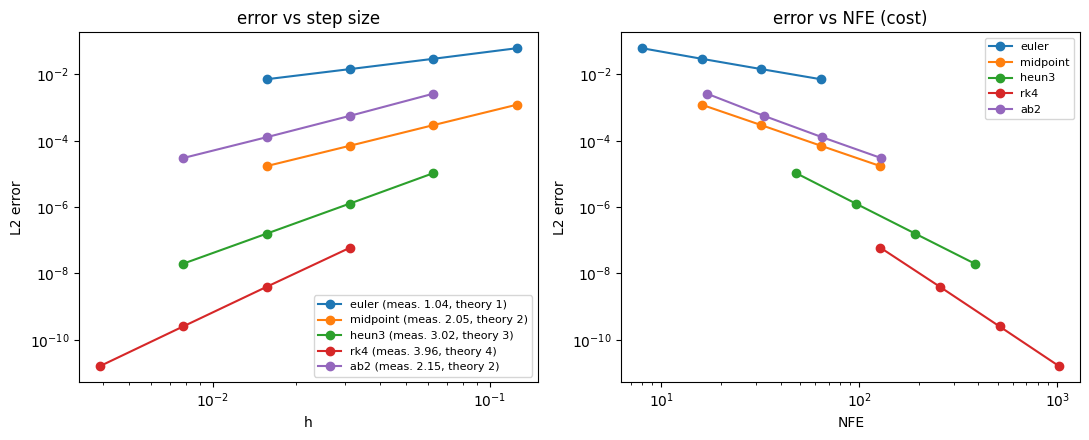

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for name, (order, ns, errs, m) in results.items():
    hs = 1.0 / np.asarray(ns)
    ax[0].loglog(hs, errs, "o-", label=f"{name} (meas. {m:.2f}, theory {order})")
    nfes = [n + 1 if name == "ab2" else NFE_PER_STEP[name] * n for n in ns]
    ax[1].loglog(nfes, errs, "o-", label=name)
ax[0].set_xlabel("h"); ax[0].set_ylabel("L2 error"); ax[0].set_title("error vs step size"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("NFE"); ax[1].set_ylabel("L2 error"); ax[1].set_title("error vs NFE (cost)"); ax[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "03_solvers_order.png", dpi=130)


## 3. Arm A vs arm B — same steppers, different grid

Same problem, same stepper (`rk4`), only the independent variable changes:
`grid_t` + `rhs_t` (arm A) vs `grid_lambda` + `rhs_lambda` (arm B). Both must
converge to the same closed-form answer.

In [5]:
tb2 = GaussianTier1(kappa=10.0, d=3, seed=1)
xT2 = tb2.x_T(4)
ref2 = tb2.exact(xT2, T, T_END)

for n in [10, 20, 40, 80]:
    ga = grid_t(T, T_END, n)
    gb = grid_lambda(T, T_END, n)
    xa, nfea = integrate(tb2.rhs_t, xT2, ga, "rk4")
    xb, nfeb = integrate(tb2.rhs_lambda, xT2, gb, "rk4")
    erra = np.sqrt(np.mean((xa - ref2) ** 2))
    errb = np.sqrt(np.mean((xb - ref2) ** 2))
    print(f"n={n:<4} arm A err={erra:.3e}   arm B err={errb:.3e}")


n=10   arm A err=4.149e-06   arm B err=5.471e-06
n=20   arm A err=2.966e-07   arm B err=4.150e-07
n=40   arm A err=1.965e-08   arm B err=2.892e-08
n=80   arm A err=1.259e-09   arm B err=1.906e-09


## 4. Divergence flagging

`integrate` must stop and report `nfe = nan` the moment a state goes
non-finite, for every stepper — the machinery M6's stability sweep relies on.

In [6]:
def explosive_rhs(x, t):
    return 1e100 * x

grid = np.linspace(0.0, 1.0, 5)
x0 = np.array([[1.0, -1.0]])
for name in list(STEPPERS) + ["ab2"]:
    xf, nfe = integrate(explosive_rhs, x0, grid, name)
    print(f"{name:<9} nfe={nfe}  finite={np.all(np.isfinite(xf))}")


euler     nfe=nan  finite=False
midpoint  nfe=nan  finite=False
heun3     nfe=nan  finite=False
rk4       nfe=nan  finite=False
ab2       nfe=nan  finite=False


C:\Users\Legion\AppData\Local\Temp\ipykernel_14692\127059941.py:2: RuntimeWarning: overflow encountered in multiply
  return 1e100 * x


## 5. Validation — run the unit tests

In [7]:
out = subprocess.run([sys.executable, "-m", "pytest", "tests/test_solvers.py", "-q"],
                     cwd=ROOT, capture_output=True, text=True)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "arm A/B solver tests failed"
print("M3 validation: PASS")


..............                                                           [100%]
============================== warnings summary ===============================
tests/test_solvers.py::test_integrate_flags_divergence[euler]
tests/test_solvers.py::test_integrate_flags_divergence[midpoint]
tests/test_solvers.py::test_integrate_flags_divergence[heun3]
tests/test_solvers.py::test_integrate_flags_divergence[rk4]
tests/test_solvers.py::test_integrate_flags_divergence[ab2]
  C:\Users\Legion\OneDrive\Desktop\NUMERICAL-PROJECT\tests\test_solvers.py:115: RuntimeWarning: overflow encountered in multiply
    return 1e100 * x

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html


M3 validation: PASS
